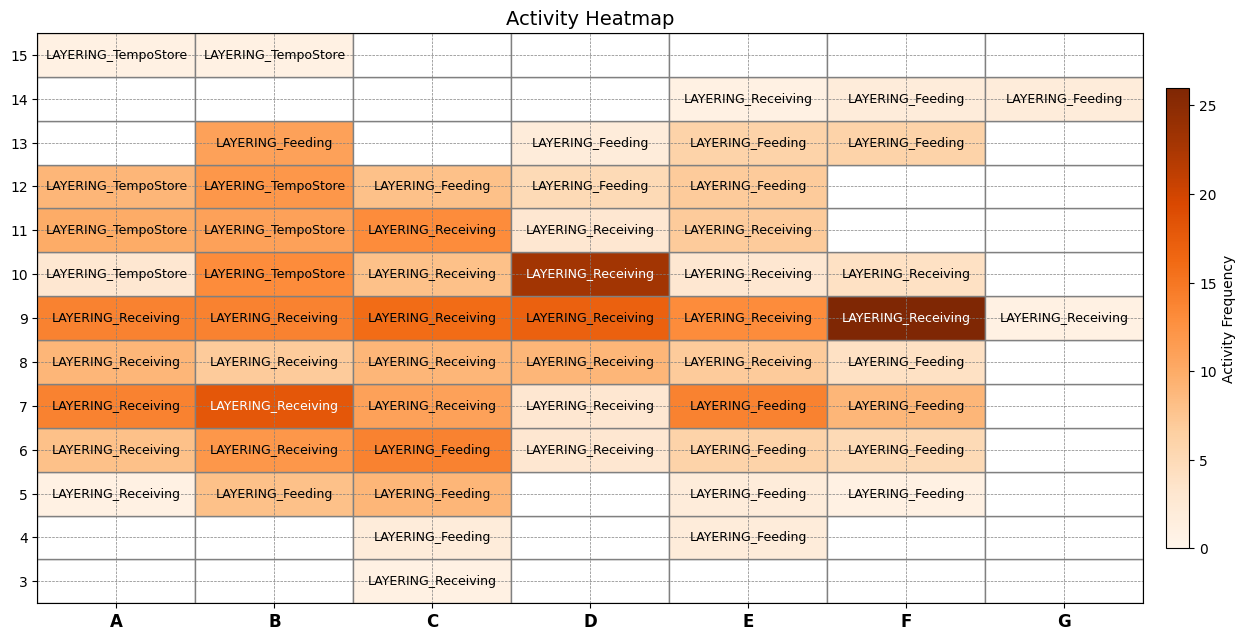

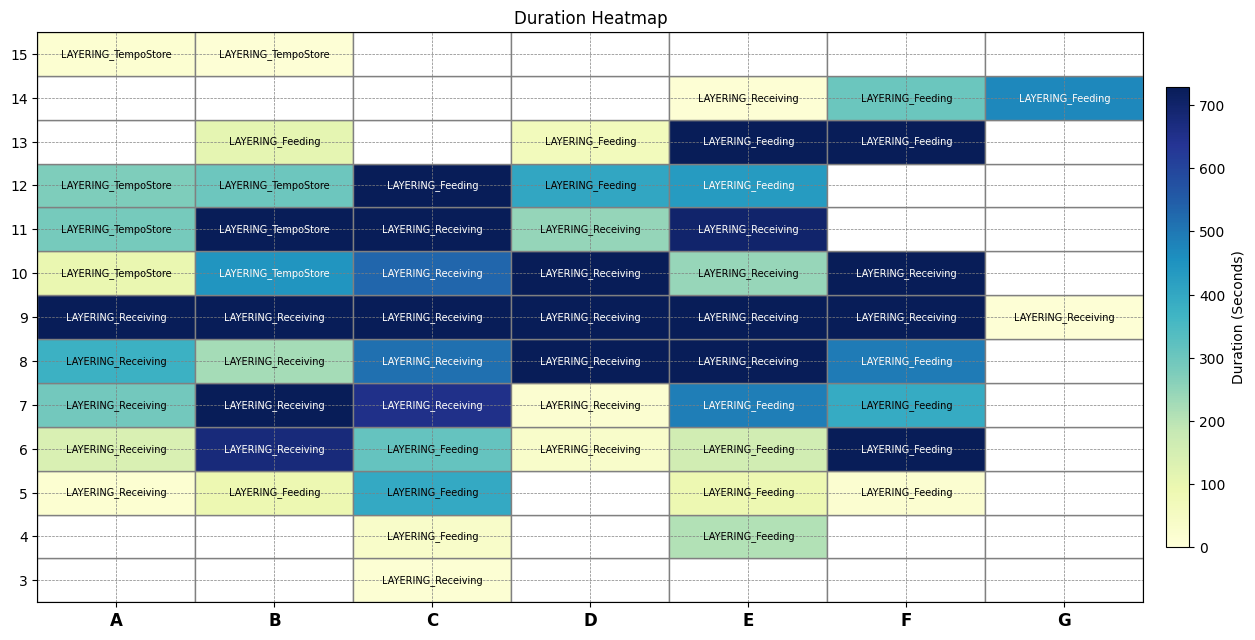

In [3]:
import tkinter as tk

from tkinter import *
from tkinter import ttk
import sqlite3

from matplotlib import cm

import mplcursors

import io

from PIL import Image


import matplotlib.colors as mcolors

import time


import matplotlib.animation as animation

import matplotlib.colors as mcolors


from mpl_toolkits.mplot3d import Axes3D


from matplotlib.widgets import Cursor




from tkinter import Frame, messagebox


from tkinter import ttk, filedialog, messagebox
import pandas as pd
import numpy as np
import threading

import matplotlib.patches as patches
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas


import webbrowser
import plotly.express as px
import os

from matplotlib.widgets import Slider, RadioButtons

import matplotlib.patches as mpatches  # Import patches for legend creation



import plotly.graph_objs as go  # Ensure you import plotly for graphing


from datetime import datetime

import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from tkinter import *
from tkinter import messagebox, filedialog
import tkinter as tk

from dash import Dash, dcc, html
from dash.dependencies import Input, Output
from matplotlib.colors import LogNorm
from tkinter import colorchooser

from tkinter import simpledialog
from collections import Counter, defaultdict







root = tk.Tk()
root.geometry('400x600')
root.title("Video Patterns Explorer")

menu_bar_colour = '#383838'

# Load icons
toggle_icon = tk.PhotoImage(file=r"C:\Users\saturn\Documents\images\toggle_btn_icon.png")
home_icon = tk.PhotoImage(file=r"C:\Users\saturn\Documents\images\home_icon.png")
service_icon = tk.PhotoImage(file=r"C:\Users\saturn\Documents\images\services_icon.png")
update_icon = tk.PhotoImage(file=r"C:\Users\saturn\Documents\images\updates_icon.png")
contact_icon = tk.PhotoImage(file=r"C:\Users\saturn\Documents\images\contact_icon.png")
about_icon = tk.PhotoImage(file=r"C:\Users\saturn\Documents\images\about_icon.png")
close_icon = tk.PhotoImage(file=r"C:\Users\saturn\Documents\images\close_btn_icon.png")

# Create page frame first
page_frame = tk.Frame(root)
page_frame.place(relwidth=1.0, relheight=1.0, x=50)

# Store pages in a dictionary
pages = {}

def open_link():
    webbrowser.open("https://video-tool-blue.vercel.app/")

        # Function to query the selected database and create the Treeview

def query_database():
    global my_tree
    db_name = filedialog.askopenfilename(defaultextension=".db", filetypes=[("Database files", "*.db")])

    if db_name:
        global current_db_path
        current_db_path = db_name

        try:
            conn = sqlite3.connect(db_name)
            c = conn.cursor()
            c.execute("SELECT * FROM video")
            records = c.fetchall()
            conn.close()

            # Clear only the data page
            data_page = pages['data']
            for widget in data_page.winfo_children():
                widget.destroy()

            # Treeview Section
            tree_frame = tk.Frame(data_page)
            tree_frame.pack(pady=20, fill="both", expand=True)

            tree_scroll = tk.Scrollbar(tree_frame)
            tree_scroll.pack(side=tk.RIGHT, fill=tk.Y)

            my_tree = ttk.Treeview(tree_frame, yscrollcommand=tree_scroll.set, selectmode="extended")
            my_tree.pack(fill="both", expand=True, padx=(0, 10), pady=(0, 10))

            tree_scroll.config(command=my_tree.yview)

            my_tree['columns'] = ("Cell Name", "Region Name", "Person Name", "Activity", "Start Time", "End Time")
            my_tree.column("#0", width=0, stretch=tk.NO)
            for col in my_tree['columns']:
                my_tree.column(col, anchor=tk.W, width=120) 
                my_tree.heading(col, text=col, anchor=tk.W)

            my_tree.tag_configure('oddrow', background='white')
            my_tree.tag_configure('evenrow', background='lightblue')
            my_tree.tag_configure('region_group', background='#dfeffc', font=('Arial', 11, 'bold'))

            if records:
                # Grouping by Region Name
                grouped_records = {}
                for record in records:
                    region = record[1]  # Assuming "Region Name" is at index 1
                    grouped_records.setdefault(region, []).append(record)

                for region, items in grouped_records.items():
                    region_id = my_tree.insert('', 'end', text='', values=(f"Region: {region}", '', '', '', '', ''), open=True, tags=('region_group',))
                    for i, record in enumerate(items):
                        tag = 'evenrow' if i % 2 == 0 else 'oddrow'
                        my_tree.insert(region_id, 'end', values=record, tags=(tag,))

                # Optionally scroll to the last item
                my_tree.yview_moveto(1)

            # Right-click popup menu
            tree_menu = tk.Menu(root, tearoff=0)
            tree_menu.add_command(label="Edit Record", command=lambda: print("Edit record"))
            tree_menu.add_command(label="Add New Record", command=add_new_record)
            tree_menu.add_command(label="Delete Record", command=lambda: print("Delete record"))
            tree_menu.add_command(label="Duplicate Record", command=lambda: print("Duplicate record"))
            tree_menu.add_command(label="Export as CSV", command=import_data)
            tree_menu.add_command(label="Filter Records", command=lambda: print("Filter records"))
            tree_menu.add_command(label="Search", command=lambda: print("Search"))
            tree_menu.add_command(label="Sort by Column", command=lambda: print("Sort by column"))
            tree_menu.add_command(label="Copy Cell Data", command=lambda: print("Copy cell data"))
            tree_menu.add_command(label="Quick Stats", command=show_quick_stats)
            tree_menu.add_separator()
            tree_menu.add_command(label="Refresh View", command=lambda: query_database())

            def show_tree_menu(event):
                try:
                    row_id = my_tree.identify_row(event.y)
                    if row_id:
                        my_tree.selection_set(row_id)
                    tree_menu.tk_popup(event.x_root, event.y_root)
                finally:
                    tree_menu.grab_release()

            my_tree.bind("<Button-3>", show_tree_menu)

            # Show info message regardless of records
            messagebox.showinfo("Success", "Data queried successfully!")

        except Exception as e:
            messagebox.showerror("Error", f"An error occurred: {str(e)}")
        
 ####################################################################################################################### 



########################################################################################################################

# Page definitions (all take a frame argument)

def home_page(frame):
    global pages
    global dashboard_inner

    # Use grid to manage layout properly
    frame.grid_rowconfigure(1, weight=1)  # Make row 1 (content area) expandable
    frame.grid_columnconfigure(0, weight=1)

    # Frame for the top options menu
    options_fm = tk.Frame(frame, height=60)
    options_fm.grid(row=0, column=0, sticky="ew")

    # Frame to hold the subpages
    content_frame = tk.Frame(frame)
    content_frame.grid(row=1, column=0, sticky="nsew")

    # Configure content_frame to expand subpages
    content_frame.grid_rowconfigure(0, weight=1)
    content_frame.grid_columnconfigure(0, weight=1)

    # Data Page
    data_page_fm = tk.Frame(content_frame, bg="white")
    data_label = tk.Label(data_page_fm, text='Video Patterns Explorer', font=('Arial', 25,'italic'), fg='#0097e8')
    data_label.pack(pady=80)
    data_page_fm.grid(row=0, column=0, sticky="nsew",padx=(0, 60))
    

    # Heatmap Page
    heatmap_page_fm = tk.Frame(content_frame, bg="white")
    heatmap_label = tk.Label(heatmap_page_fm, text='Heatmap Plot Page', font=('Arial', 25,'italic'), fg='#0097e8')
    heatmap_label.pack(pady=80)
    heatmap_page_fm.grid(row=0, column=0, sticky="nsew")

    # Spaghetti Page
    spaghetti_page_fm = tk.Frame(content_frame, bg="white")
    spaghetti_label = tk.Label(spaghetti_page_fm, text='Spaghetti Plot Page', font=('Arial', 25,'italic'), fg='#0097e8')
    spaghetti_label.pack(pady=80)
    spaghetti_page_fm.grid(row=0, column=0, sticky="nsew")

     # gantt plot Page
    gantt_page_fm = tk.Frame(content_frame, bg="white")
    gantt_label = tk.Label(gantt_page_fm, text='Process Plot Page', font=('Arial', 25,'italic'), fg='#0097e8')
    gantt_label.pack(pady=80)
    gantt_page_fm.grid(row=0, column=0, sticky="nsew")

     # box plot Page
    box_page_fm = tk.Frame(content_frame, bg="white")
    box_label = tk.Label(box_page_fm, text='Analytics Polt Page', font=('Arial', 25,'italic'), fg='#0097e8')
    box_label.pack(pady=80)
    box_page_fm.grid(row=0, column=0, sticky="nsew")

     # stacked bar Page
    stacked_page_fm = tk.Frame(content_frame, bg="white")
    stacked_label = tk.Label(stacked_page_fm, text='Timeline Plot Page', font=('Arial', 25,'italic'), fg='#0097e8')
    stacked_label.pack(pady=80)
    stacked_page_fm.grid(row=0, column=0, sticky="nsew")

     # pareto Page
    pareto_page_fm = tk.Frame(content_frame, bg="white")
    pareto_label = tk.Label(pareto_page_fm, text='Statistics Plot Page', font=('Arial', 25,'italic'), fg='#0097e8')
    pareto_label.pack(pady=80)
    pareto_page_fm.grid(row=0, column=0, sticky="nsew")

     # pie Page
    pie_page_fm = tk.Frame(content_frame, bg="white")
    pie_label = tk.Label(pie_page_fm, text='Comparison Plot Page', font=('Arial', 25,'italic'), fg='#0097e8')
    pie_label.pack(pady=80)
    pie_page_fm.grid(row=0, column=0, sticky="nsew")

     # histogram Page
    histogram_page_fm = tk.Frame(content_frame, bg="white")
    histogram_label = tk.Label(histogram_page_fm, text='Explore Plot Page', font=('Arial', 25,'italic'), fg='#0097e8')
    histogram_label.pack(pady=80)
    histogram_page_fm.grid(row=0, column=0, sticky="nsew")

     # Dashboard Page
    # Dashboard Page (formerly called scatter)
    # Ensure content_frame is stretchable
    content_frame.grid_rowconfigure(0, weight=1)
    content_frame.grid_columnconfigure(0, weight=1)
    
    # Scatter page frame
    scatter_page_fm = tk.Frame(content_frame, bg="white")
    scatter_page_fm.grid(row=0, column=0, sticky="nsew",padx=(0, 60))
    
    # Canvas and Scrollbar
    dashboard_canvas = tk.Canvas(scatter_page_fm, bg="white")
    dashboard_canvas.pack(fill="both", expand=True, side="left")
    
    scroll_y = tk.Scrollbar(scatter_page_fm, orient="vertical", command=dashboard_canvas.yview)
    scroll_y.pack(side="right", fill="y")
    
    dashboard_canvas.configure(yscrollcommand=scroll_y.set)
    
    # Frame inside canvas
    dashboard_inner = tk.Frame(dashboard_canvas, bg="white")
    dashboard_window = dashboard_canvas.create_window((0, 0), window=dashboard_inner, anchor="nw")
    
    def configure_scroll(event):
        dashboard_canvas.configure(scrollregion=dashboard_canvas.bbox("all"))
    
    dashboard_inner.bind("<Configure>", configure_scroll)


    



    # Stack all subpages
    subpages = {
        'data': data_page_fm,
        'heatmap': heatmap_page_fm,
        'spaghetti': spaghetti_page_fm,
        'gantt': gantt_page_fm,
        'box': box_page_fm,
        'stacked': stacked_page_fm,
        'pareto': pareto_page_fm,
        'pie': pie_page_fm,
        'histogram': histogram_page_fm,
        'scatter': scatter_page_fm
    }

    pages['data'] = data_page_fm
    pages['heatmap'] = heatmap_page_fm
    pages['spaghetti'] = spaghetti_page_fm
    pages['gantt'] = gantt_page_fm
    pages['box'] = box_page_fm
    pages['stacked'] = stacked_page_fm
    pages['pareto'] = pareto_page_fm
    pages['pie'] = pie_page_fm
    pages['histogram'] = histogram_page_fm
    pages['scatter'] = scatter_page_fm


    

    # create dropdown for heatmaps 

    




    # Home page menu buttons
    data_indicator_lb = tk.Label(options_fm, bg='#0097e8')
    heatmap_indicator_lb = tk.Label(options_fm, bg='#0097e8')
    spaghetti_indicator_lb = tk.Label(options_fm, bg='#0097e8')
    gantt_indicator_lb = tk.Label(options_fm, bg='#0097e8')
    box_indicator_lb = tk.Label(options_fm, bg='#0097e8')
    stacked_indicator_lb = tk.Label(options_fm, bg='#0097e8')
    pareto_indicator_lb = tk.Label(options_fm, bg='#0097e8')
    pie_indicator_lb = tk.Label(options_fm, bg='#0097e8')
    histogram_indicator_lb = tk.Label(options_fm, bg='#0097e8')
    scatter_indicator_lb = tk.Label(options_fm, bg='#0097e8')

    def switch(page_name):
        # Hide all indicators
        data_indicator_lb.place_forget()
        heatmap_indicator_lb.place_forget()
        spaghetti_indicator_lb.place_forget()
        gantt_indicator_lb.place_forget()
        box_indicator_lb.place_forget()
        stacked_indicator_lb.place_forget()
        pareto_indicator_lb.place_forget()
        pie_indicator_lb.place_forget()
        histogram_indicator_lb.place_forget()
        scatter_indicator_lb.place_forget()

        # Raise the selected page
        subpages[page_name].tkraise()

        # Show the indicator for the active page
        if page_name == 'data':
            data_indicator_lb.place(x=22, y=40, width=80, height=2)
        elif page_name == 'heatmap':
            heatmap_indicator_lb.place(x=147, y=40, width=80, height=2)
        elif page_name == 'spaghetti':
            spaghetti_indicator_lb.place(x=272, y=40, width=80, height=2)

        elif page_name == 'gantt':
            gantt_indicator_lb.place(x=397, y=40, width=80, height=2)

        elif page_name == 'box':
            box_indicator_lb.place(x=525, y=40, width=80, height=2)

        elif page_name == 'stacked':
            stacked_indicator_lb.place(x=647, y=40, width=80, height=2)

        elif page_name == 'pareto':
            pareto_indicator_lb.place(x=772, y=40, width=80, height=2)

        elif page_name == 'pie':
            pie_indicator_lb.place(x=897, y=40, width=80, height=2)

        elif page_name == 'histogram':
            histogram_indicator_lb.place(x=1022, y=40, width=80, height=2)

        elif page_name == 'scatter':
            scatter_indicator_lb.place(x=1147, y=40, width=80, height=2)

    data_btn = tk.Button(options_fm, text='📊\nData', font=("Arial", 13),
                         bd=0, fg='#0097e8', activebackground='#0097e8',
                         command=lambda: switch('data'))#, data_menu.post(data_btn.winfo_rootx(), data_btn.winfo_rooty() + data_btn.winfo_height())])
    data_btn.place(x=0, y=0, width=125, height=40)

    heatmap_btn = tk.Button(options_fm, text='🔥\nHeatmaps', font=("Arial", 13),
                            bd=0, fg='#0097e8', activebackground='#0097e8',
                            command=lambda: switch('heatmap'))
    heatmap_btn.place(x=125, y=0, width=125, height=40)

    spaghetti_btn = tk.Button(options_fm, text='🧭\nMovement', font=("Arial", 13),
                               bd=0, fg='#0097e8', activebackground='#0097e8',
                               command=lambda: switch('spaghetti'))
    spaghetti_btn.place(x=250, y=0, width=125, height=40)

    gantt_btn = tk.Button(options_fm, text='🔁\nProcess Flow', font=("Arial", 13),
                               bd=0, fg='#0097e8', activebackground='#0097e8',
                               command=lambda: switch('gantt'))
    gantt_btn.place(x=375, y=0, width=125, height=40)

    box_btn = tk.Button(options_fm, text='📈\nAnalytics', font=("Arial", 13),
                               bd=0, fg='#0097e8', activebackground='#0097e8',
                               command=lambda: switch('box'))
    box_btn.place(x=500, y=0, width=125, height=40)

    stacked_btn = tk.Button(options_fm, text='📅\nTimeline', font=("Arial", 13),
                               bd=0, fg='#0097e8', activebackground='#0097e8',
                               command=lambda: switch('stacked'))
    stacked_btn.place(x=625, y=0, width=125, height=40)

    pareto_btn = tk.Button(options_fm, text='📊\nStatistics', font=("Arial", 13),
                               bd=0, fg='#0097e8', activebackground='#0097e8',
                               command=lambda: switch('pareto'))
    pareto_btn.place(x=750, y=0, width=125, height=40)

    pie_btn = tk.Button(options_fm, text='🧩\nComparison', font=("Arial", 13),
                               bd=0, fg='#0097e8', activebackground='#0097e8',
                               command=lambda: switch('pie'))
    pie_btn.place(x=875, y=0, width=125, height=40)

    histogram_btn = tk.Button(options_fm, text='🔍\nExplore', font=("Arial", 13),
                               bd=0, fg='#0097e8', activebackground='#0097e8',
                               command=lambda: switch('histogram'))
    histogram_btn.place(x=1000, y=0, width=125, height=40)

    scatter_btn = tk.Button(options_fm, text='🧮\nDashboard', font=("Arial", 13),
                               bd=0, fg='#0097e8', activebackground='#0097e8',
                               command=lambda: switch('scatter'))
    scatter_btn.place(x=1125, y=0, width=125, height=40)

    # Create vertical dropdown menu for Data button
    data_menu = tk.Menu(root, tearoff=0)
    data_menu.add_command(label="New", command=create_database)
    data_menu.add_command(label="Open", command=query_database)
    data_menu.add_command (label = "Open Video Analysis" ,  command=open_link)
    data_menu.add_command(label="Save", command=lambda: print("Save File"))
    data_menu.add_separator()
    data_menu.add_command(label="Exit", command=root.quit)
    
    # Function to show data menu on right-click
    def show_data_menu(event):
        data_menu.tk_popup(event.x_root, event.y_root)
    
    # Bind right-click (Button-3) to the existing data_btn
    data_btn.bind("<Button-3>", show_data_menu)



    # Create the dropdown menu
    heatmap_menu = tk.Menu(root, tearoff=0)
    heatmap_menu.add_command(label="Combined Heatmap", command=generate_combined_heatmap)
    heatmap_menu.add_command(label="Activity Heatmap", command=generate_activity_heatmap)
    heatmap_menu.add_command(label="Duration Heatmap", command=generate_duration_heatmap)
    heatmap_menu.add_command(label="Time-Sliced Heatmap", command=generate_time_sliced_heatmap)
    heatmap_menu.add_command(label="Worker-Activity Matrix", command=generate_worker_activity_matrix)
    
    # Define function to show the menu
    def show_heatmap_menu(event):
        heatmap_menu.tk_popup(event.x_root, event.y_root)
    
    # Bind right-click (Button-3) to the existing heatmap button
    heatmap_btn.bind("<Button-3>", show_heatmap_menu)

    # Create the dropdown menu
    spaghetti_menu = tk.Menu(root, tearoff=0)
    spaghetti_menu.add_command(label="Spaghetti Plot", command=generate_spaghetti_diagram)
    spaghetti_menu.add_command(label="Worker Path Density", command=generate_worker_path_density)
    spaghetti_menu.add_command(label="Movement Pattern Clusters", command=generate_movement_pattern_clusters)
    
    
    # Define function to show the menu
    def show_spaghetti_menu(event):
        spaghetti_menu.tk_popup(event.x_root, event.y_root)
    
    # Bind right-click (Button-3) to the existing heatmap button
    spaghetti_btn.bind("<Button-3>", show_spaghetti_menu)

    # Create the dropdown menu
    gantt_menu = tk.Menu(root, tearoff=0)
    gantt_menu.add_command(label="Activity Network Diagram", command=generate_activity_network_diagram)
    
    
    
    # Define function to show the menu
    def show_gantt_menu(event):
        gantt_menu.tk_popup(event.x_root, event.y_root)
    
    # Bind right-click (Button-3) to the existing heatmap button
    gantt_btn.bind("<Button-3>", show_gantt_menu)

    # Create the dropdown menu
    box_menu = tk.Menu(root, tearoff=0)
    box_menu.add_command(label="Time Series", command=generate_time_series)
    box_menu.add_command(label="Worker Speed Over Time", command=generate_worker_speed_over_time)
    
    
    
    # Define function to show the menu
    def show_box_menu(event):
        box_menu.tk_popup(event.x_root, event.y_root)
    
    # Bind right-click (Button-3) to the existing heatmap button
    box_btn.bind("<Button-3>", show_box_menu)

    # Create the dropdown menu
    stacked_menu = tk.Menu(root, tearoff=0)
    stacked_menu.add_command(label="Gantt Chart", command= generate_gantt_chart_page)
   
    
    
    
    # Define function to show the menu
    def show_stacked_menu(event):
        stacked_menu.tk_popup(event.x_root, event.y_root)
    
    # Bind right-click (Button-3) to the existing heatmap button
    stacked_btn.bind("<Button-3>", show_stacked_menu)

    # Create the dropdown menu
    pareto_menu = tk.Menu(root, tearoff=0)
    pareto_menu.add_command(label="Histogram", command=generate_activity_duration_histogram)
    pareto_menu.add_command(label="Box Plot", command=generate_activity_duration_boxplot)
    
    
    
    
    # Define function to show the menu
    def show_pareto_menu(event):
        pareto_menu.tk_popup(event.x_root, event.y_root)
    
    # Bind right-click (Button-3) to the existing heatmap button
    pareto_btn.bind("<Button-3>", show_pareto_menu)

    # Create the dropdown menu
    pie_menu = tk.Menu(root, tearoff=0)
    pie_menu.add_command(label="Stacked Bar", command=generate_stacked_bar_chart)
    pie_menu.add_command(label="Pareto Chart", command=generate_pareto_chart)
    pie_menu.add_command(label="Pie Chart", command=generate_activity_pie_chart)
    
    
    
    
    # Define function to show the menu
    def show_pie_menu(event):
        pie_menu.tk_popup(event.x_root, event.y_root)
    
    # Bind right-click (Button-3) to the existing heatmap button
    pie_btn.bind("<Button-3>", show_pie_menu)

    # Create the dropdown menu
    histogram_menu = tk.Menu(root, tearoff=0)
    histogram_menu.add_command(label="Scatter Plot", command=generate_activity_scatter_plot)
    
    
    
    
    
    # Define function to show the menu
    def show_histogram_menu(event):
        histogram_menu.tk_popup(event.x_root, event.y_root)
    
    # Bind right-click (Button-3) to the existing heatmap button
    histogram_btn.bind("<Button-3>", show_histogram_menu)




    
    


    # Show Data Page by default
    switch('data')




def service_page(frame):
    lb = tk.Label(frame, text='Service Page', font=("Bold", 20))
    lb.place(x=100, y=200)

def update_page(frame):
    lb = tk.Label(frame, text='Update Page', font=("Bold", 20))
    lb.place(x=100, y=200)

def contact_page(frame):
    lb = tk.Label(frame, text='Contact Page', font=("Bold", 20))
    lb.place(x=100, y=200)

def about_page(frame):
    lb = tk.Label(frame, text='About Page', font=("Bold", 20))
    lb.place(x=100, y=200)

def create_pages():
    for name, page_fn in {
        'home': home_page,
        'service': service_page,
        'update': update_page,
        'contact': contact_page,
        'about': about_page
    }.items():
        frame = tk.Frame(page_frame)
        page_fn(frame)
        frame.place(relwidth=1, relheight=1)
        pages[name] = frame

def switch_page(name, indicator_lb):
    # Reset indicators
    for lb in [home_indicate, service_indicate, update_indicate, contact_indicate, about_indicate]:
        lb.config(bg=menu_bar_colour)
    indicator_lb.config(bg='white')

    if menu_bar_frame.winfo_width() > 45:
        fold_menu_bar()

    pages[name].tkraise()

# Animation functions
def extending_animation():
    current_width = menu_bar_frame.winfo_width()
    if current_width < 200:
        menu_bar_frame.config(width=current_width + 10)
        root.after(8, extending_animation)

def extend_menu_bar():
    extending_animation()
    toggle_menu_btn.config(image=close_icon, command=fold_menu_bar)

def folding_animation():
    current_width = menu_bar_frame.winfo_width()
    if current_width > 45:
        menu_bar_frame.config(width=current_width - 10)
        root.after(8, folding_animation)

def fold_menu_bar():
    folding_animation()
    toggle_menu_btn.config(image=toggle_icon, command=extend_menu_bar)


def create_database():
    
        
        
    db_name = filedialog.asksaveasfilename(defaultextension=".db", filetypes=[("Database files", "*.db")])
            
    if db_name:
            
        try:
            conn = sqlite3.connect(db_name)
            c = conn.cursor()
        
            c.execute(""" CREATE TABLE IF NOT EXISTS video(
                        cell_name TEXT,
                        region_name TEXT,
                        person_name TEXT,
                        activity TEXT,
                        start_time TEXT,
                        end_time TEXT,
                        UNIQUE(cell_name, region_name, person_name, activity, start_time, end_time)
                        )
                    """)
        
            conn.commit()
            conn.close()
            messagebox.showinfo("Success", f"Database '{db_name}' created successfully!")
        except Exception as e:
            messagebox.showerror("Error", f"An error occurred: {str(e)}")
    
    ################################################################################################################################

def import_data():
    if not current_db_path:
        messagebox.showwarning("No Database", "Please open a database first.")
        return

    file_path = filedialog.askopenfilename(filetypes=[("CSV files", "*.csv"), ("Excel files", "*.xlsx;*.xls")])
    if file_path:
        try:
            user_date = simpledialog.askstring("Recording Date", "Enter the date the data was recorded (YYYY-MM-DD):")
            if not user_date:
                messagebox.showwarning("Cancelled", "Import cancelled. No date provided.")
                return

            try:
                recording_date = datetime.strptime(user_date.strip(), "%Y-%m-%d").date()
            except ValueError:
                messagebox.showerror("Invalid Date", "Please enter the date in YYYY-MM-DD format.")
                return

            # --- only this part changed ---
            if file_path.endswith('.csv'):
                try:
                    # Auto-detect delimiter (comma or semicolon) and skip comment lines
                    data = pd.read_csv(file_path, sep=None, engine="python", comment="#")
                except Exception:
                    # Fallback if detection fails
                    try:
                        data = pd.read_csv(file_path, delimiter=';', comment="#")
                    except Exception:
                        data = pd.read_csv(file_path, delimiter=',', comment="#")
            else:
                data = pd.read_excel(file_path)
            # --- end of change ---

            data.columns = [col.strip().lower().replace(" ", "_") for col in data.columns]
            required_cols = {'cell_name', 'region_name', 'person_name', 'activity', 'start_time', 'end_time'}
            if not required_cols.issubset(set(data.columns)):
                raise ValueError("Missing one or more required columns.")

            data['start_time'] = pd.to_datetime(
                recording_date.strftime('%Y-%m-%d') + ' ' + data['start_time'].astype(str).str.strip(),
                errors='coerce'
            )
            data['end_time'] = pd.to_datetime(
                recording_date.strftime('%Y-%m-%d') + ' ' + data['end_time'].astype(str).str.strip(),
                errors='coerce'
            )

            data.dropna(subset=['start_time', 'end_time'], inplace=True)

            conn = sqlite3.connect(current_db_path)
            c = conn.cursor()

            imported_count = 0

            for _, row in data.iterrows():
                start_str = row['start_time'].strftime('%Y-%m-%d %H:%M:%S')
                end_str = row['end_time'].strftime('%Y-%m-%d %H:%M:%S')

                c.execute("""
                    SELECT COUNT(*) FROM video
                    WHERE cell_name = ? AND region_name = ? AND person_name = ?
                          AND activity = ? AND start_time = ? AND end_time = ?
                """, (
                    row['cell_name'],
                    row['region_name'],
                    row['person_name'],
                    row['activity'],
                    start_str,
                    end_str
                ))

                if c.fetchone()[0] > 0:
                    response = messagebox.askyesnocancel(
                        "Duplicate Entry Found",
                        f"Duplicate found:\n\n"
                        f"Cell: {row['cell_name']}\nRegion: {row['region_name']}\n"
                        f"Person: {row['person_name']}\nActivity: {row['activity']}\n"
                        f"Start: {start_str}\nEnd: {end_str}\n\n"
                        "Do you want to insert it again?"
                    )

                    if response is None:  # Cancel
                        messagebox.showinfo("Cancelled", "Import process cancelled by user.")
                        conn.close()
                        return
                    elif not response:  # No
                        continue
                    # Yes → insert the row

                c.execute("""
                    INSERT INTO video (cell_name, region_name, person_name, activity, start_time, end_time)
                    VALUES (?, ?, ?, ?, ?, ?)
                """, (
                    row['cell_name'],
                    row['region_name'],
                    row['person_name'],
                    row['activity'],
                    start_str,
                    end_str
                ))
                imported_count += 1

            conn.commit()
            conn.close()

            messagebox.showinfo("Success", f"Import complete.\n\n{imported_count} new row(s) added.")
            query_database()

        except Exception as e:
            messagebox.showerror("Error", str(e))


##############################################################################################################################

def add_new_record():
    popup = tk.Toplevel()
    popup.title("Add New Record")
    popup.geometry("400x400")

    labels = ["Cell Name", "Region Name", "Person Name", "Activity", "Start Time", "End Time"]
    entries = {}

    for idx, label in enumerate(labels):
        tk.Label(popup, text=label).grid(row=idx, column=0, padx=10, pady=5, sticky='w')
        entry = tk.Entry(popup, width=30)
        entry.grid(row=idx, column=1, padx=10, pady=5)
        entries[label] = entry

    def save_record():
        values = [entries[label].get() for label in labels]
        if not all(values):
            messagebox.showwarning("Input Error", "Please fill in all fields.")
            return

        try:
            conn = sqlite3.connect(current_db_path)
            c = conn.cursor()
            c.execute("INSERT INTO video (cell_name, region_name, person_name, activity, start_time, end_time) VALUES (?, ?, ?, ?, ?, ?)", values)
            conn.commit()
            conn.close()
            popup.destroy()
            query_database()  # Refresh view
            messagebox.showinfo("Success", "Record added successfully!")
        except Exception as e:
            messagebox.showerror("Database Error", str(e))

    tk.Button(popup, text="Add Record", command=save_record).grid(row=len(labels), column=0, columnspan=2, pady=20)

##############################################################################################################################


def show_quick_stats():
    if not my_tree.get_children():
        messagebox.showinfo("Stats", "No data loaded.")
        return

    total_records = 0
    person_set = set()
    activity_set = set()
    total_duration = 0

    activity_counter = Counter()
    person_duration = defaultdict(float)

    for region_id in my_tree.get_children():
        for child_id in my_tree.get_children(region_id):
            values = my_tree.item(child_id, 'values')
            if not values or "Region" in values[0]:
                continue

            total_records += 1
            person = values[2]
            activity = values[3]
            person_set.add(person)
            activity_set.add(activity)
            activity_counter[activity] += 1

            # Duration
            try:
                start = float(values[4])
                end = float(values[5])
                duration = max(0, end - start)
                total_duration += duration
                person_duration[person] += duration
            except:
                pass

    # Top stats
    most_common_activity = activity_counter.most_common(1)[0] if activity_counter else ("N/A", 0)
    most_active_person = max(person_duration.items(), key=lambda x: x[1]) if person_duration else ("N/A", 0)

    msg = (
        f"📊 Quick Stats:\n\n"
        f"Total Records: {total_records}\n"
        f"Unique Persons: {len(person_set)}\n"
        f"Unique Activities: {len(activity_set)}\n"
        f"Total Duration: {round(total_duration, 2)} seconds\n\n"
        f"🔥 Most Frequent Activity: {most_common_activity[0]} ({most_common_activity[1]} times)\n"
        f"🏃 Most Active Person: {most_active_person[0]} ({round(most_active_person[1], 2)} seconds)"
    )

    messagebox.showinfo("Quick Stats", msg)




###############################################################################################################################




def generate_combined_heatmap():
    """Generate a combined heatmap overlaying worker presence, activities, and duration."""

    heatmap_page = pages['heatmap']
    for widget in heatmap_page.winfo_children():
        widget.destroy()

    heatmap_frame = tk.Frame(heatmap_page)
    heatmap_frame.pack(pady=10, fill="both", expand=True)

    current_cmap = 'YlGnBu'

   

    def fetch_data():
        if current_db_path is None:
            messagebox.showerror("Error", "Database path is not set.")
            return pd.DataFrame()
        try:
            conn = sqlite3.connect(current_db_path)
            query = """
                SELECT cell_name, region_name, person_name, activity,
                       (strftime('%s', end_time) - strftime('%s', start_time)) AS duration 
                FROM video
            """
            df = pd.read_sql(query, conn)
            conn.close()
            return df
        except Exception as e:
            messagebox.showerror("Database Error", str(e))
            return pd.DataFrame()

    def create_heatmap():
        df = fetch_data()
        if df.empty:
            messagebox.showerror("Data Error", "No data returned from the database.")
            return

        workers = df['person_name'].unique()
        activities = df['activity'].unique()

        worker_colors = plt.get_cmap('tab10', len(workers))
        activity_colors = plt.get_cmap('Set3', len(activities))

        worker_color_map = {worker: worker_colors(i) for i, worker in enumerate(workers)}
        activity_color_map = {activity: activity_colors(i) for i, activity in enumerate(activities)}

        fig, ax = plt.subplots(figsize=(8, 10))
        plt.subplots_adjust(left=0.1, right=0.75, top=0.9, bottom=0.1)

        unique_cells = sorted(set(df['cell_name'].unique()))
        letters = sorted(set(c[0] for c in unique_cells))
        numbers = sorted(set(int(c[1:]) for c in unique_cells))

        grid_layout = {f"{letter}{num}": (i, j) for i, num in enumerate(numbers) for j, letter in enumerate(letters)}

        max_duration = df['duration'].max() if not df['duration'].isnull().all() else 1
        cmap = plt.cm.YlGnBu

        for cell, (i, j) in grid_layout.items():
            duration = df.loc[df['cell_name'] == cell, 'duration'].sum() if cell in df['cell_name'].values else 0
            color = cmap(duration / max_duration) if duration > 0 else 'white'
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, facecolor=color, edgecolor='gray'))

        for cell, (i, j) in grid_layout.items():
            if cell in df['cell_name'].values:
                for _, row in df[df['cell_name'] == cell].iterrows():
                    worker_color = worker_color_map[row['person_name']]
                    activity_color = activity_color_map[row['activity']]
                    ax.add_patch(plt.Circle((j, i), 0.2, color=worker_color, alpha=0.6))
                    ax.add_patch(plt.Circle((j, i - 0.3), 0.2, color=activity_color, alpha=0.6))

        legend_ax = fig.add_axes([0.8, 0.1, 0.15, 0.4])
        legend_ax.axis('off')
        worker_legend_patches = [mpatches.Patch(color=color, label=worker) for worker, color in worker_color_map.items()]
        legend_ax.legend(handles=worker_legend_patches, loc='upper left', title='Workers', fontsize=8)

        activity_legend_ax = fig.add_axes([0.8, 0.5, 0.15, 0.3])
        activity_legend_ax.axis('off')
        activity_legend_patches = [mpatches.Patch(color=color, label=activity) for activity, color in activity_color_map.items()]
        activity_legend_ax.legend(handles=activity_legend_patches, loc='upper left', title='Activities', fontsize=8)

        cbar_ax = fig.add_axes([0.01, 0.1, 0.03, 0.8])
        norm = plt.Normalize(vmin=0, vmax=max_duration)
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, cax=cbar_ax)
        cbar.set_label('Duration (Seconds)', rotation=270, labelpad=15)

        ax.set_xticks(range(len(letters)))
        ax.set_xticklabels(letters, fontsize=12, weight='bold')
        ax.set_yticks(range(len(numbers)))
        ax.set_yticklabels(numbers)
        ax.set_xlim(-0.5, len(letters) - 0.5)
        ax.set_ylim(-0.5, len(numbers) - 0.5)
        ax.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray')
        ax.set_title('Combined Heatmap: Workers, Activities, and Duration')

        canvas = FigureCanvasTkAgg(fig, master=heatmap_frame)
        canvas.draw()
        canvas.get_tk_widget().pack(fill=BOTH, expand=True)

        # Add right-click dropdown menu
        heatmap_menu = tk.Menu(canvas.get_tk_widget(), tearoff=0)
        heatmap_menu.add_command(label="Send to Dashboard", command=lambda: send_figure_to_dashboard(fig))
        heatmap_menu.add_command(label="Filter", command=lambda: print("Filter"))
        heatmap_menu.add_command(label="Save", command=lambda f=fig: save_figure(f))
        
        def show_heatmap_menu(event):
            try:
                heatmap_menu.tk_popup(event.x_root, event.y_root)
            finally:
                heatmap_menu.grab_release()

        canvas.get_tk_widget().bind("<Button-3>", show_heatmap_menu)

    create_heatmap()
    messagebox.showinfo("Success", "Heatmap has been generated successfully!")
  
  



###########################################################################################################################




from tkinter import filedialog, messagebox

def save_figure(fig):
    """Open a save dialog and save the matplotlib figure as an image."""
    file_path = filedialog.asksaveasfilename(
        title="Save Figure As",
        defaultextension=".png",
        filetypes=[
            ("PNG Image", "*.png"),
            ("JPEG Image", "*.jpg"),
            ("PDF Document", "*.pdf"),
            ("All Files", "*.*")
        ]
    )
    if file_path:
        try:
            fig.savefig(file_path, dpi=300, bbox_inches="tight")
            messagebox.showinfo("Success", f"Figure saved as:\n{file_path}")
        except Exception as e:
            messagebox.showerror("Error", f"Could not save the file:\n{str(e)}")


#######################################################################################################################
import io
from PIL import Image, ImageTk
def send_figure_to_dashboard(fig):
    global dashboard_inner

    try:
        # Convert the Matplotlib figure to a PNG image in memory
        buf = io.BytesIO()
        fig.savefig(buf, format='png')
        buf.seek(0)
        image = Image.open(buf)

        # Convert to ImageTk for displaying in Tkinter
        image_tk = ImageTk.PhotoImage(image)

        # Create a Frame to wrap the image (optional: helps with placement)
        image_frame = tk.Frame(dashboard_inner, bg="white", bd=2, relief="groove")
        image_frame.pack(padx=10, pady=10, anchor="nw")  # Makes sure it stacks top-left

        # Create the label inside the frame
        image_label = tk.Label(image_frame, image=image_tk, bg="white")
        image_label.image = image_tk  # Prevent garbage collection
        image_label.pack()

        # Delete button
        tk.Button(image_frame, text="❌", fg="red", command=image_frame.destroy).pack(side="left")

        # Make the frame draggable
        def start_drag(event):
            image_frame.startX = event.x
            image_frame.startY = event.y

        def do_drag(event):
            x = image_frame.winfo_x() + event.x - image_frame.startX
            y = image_frame.winfo_y() + event.y - image_frame.startY
            image_frame.place(x=x, y=y)

        image_frame.bind("<Button-1>", start_drag)
        image_frame.bind("<B1-Motion>", do_drag)

        # Confirmation
        messagebox.showinfo("Success", "Image sent to dashboard successfully!")

    except Exception as e:
        messagebox.showerror("Error", f"Failed to send image to dashboard:\n{e}")



##########################################################################################################################

def show_filter_popup(filter_type, df, plot_func, frame):
    popup = tk.Toplevel()
    popup.title(f"Filter by {filter_type.capitalize()}")

    key = f"{filter_type}_name"
    if key not in df.columns:
        messagebox.showerror("Error", f"'{key}' column not found in DataFrame.")
        return

    tk.Label(popup, text=f"Select {filter_type.capitalize()}:").pack(pady=5)
    options = sorted(df[key].dropna().unique())
    var = tk.StringVar()
    combo = ttk.Combobox(popup, textvariable=var, values=options, state="readonly")
    combo.pack(pady=5)

    def apply_filter():
        selected = var.get()
        if selected:
            filtered_df = df[df[key] == selected]
            for widget in frame.winfo_children():
                widget.destroy()
            plot_func(filtered_df, frame)
        popup.destroy()

    tk.Button(popup, text="Apply", command=apply_filter).pack(pady=5)

#########################################################################################################################

def change_plot_color(fig, ax):
    try:
        lines = ax.get_lines()
        if not lines:
            messagebox.showwarning("No Plot", "No lines found to recolor.")
            return

        cmap = plt.get_cmap('tab10')
        for line, color in zip(lines, cmap.colors):
            line.set_color(color)
        fig.canvas.draw()
    except Exception as e:
        messagebox.showerror("Color Error", f"Failed to change color: {str(e)}")



##########################################################################################################################

def choose_and_change_color(fig, ax):
    cmap_options = ['tab10', 'Set2', 'Accent', 'Paired']
    popup = tk.Toplevel()
    popup.title("Choose Color Scheme")

    var = tk.StringVar(value='tab10')
    combo = ttk.Combobox(popup, textvariable=var, values=cmap_options, state="readonly")
    combo.pack(pady=5)

    def apply_color():
        change_plot_color(fig, ax, cmap_name=var.get())
        popup.destroy()

    tk.Button(popup, text="Apply", command=apply_color).pack(pady=5)

###########################################################################################################################

def add_comment_to_plot(fig, ax):
    comment_text = simpledialog.askstring("Add Comment", "Enter your comment for the plot:")
    if comment_text:
        text_obj = ax.text(0.01, 0.95 - 0.05 * len(comments), comment_text,
                           transform=ax.transAxes, fontsize=10,
                           verticalalignment='top',
                           bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.5),
                           picker=True)
        comments.append(text_obj)
        fig.canvas.draw()

################################################################################################################################
def on_pick(event):
    picked = event.artist
    if picked in comments:
        action = messagebox.askquestion("Edit or Delete", "Do you want to edit this comment?", icon='question')
        if action == 'yes':
            new_text = simpledialog.askstring("Edit Comment", "Update the comment:", initialvalue=picked.get_text())
            if new_text:
                picked.set_text(new_text)
        else:
            picked.remove()
            comments.remove(picked)
        fig.canvas.draw()






##########################################################################################################################

import matplotlib.dates as mdates
import matplotlib.ticker as mticker

def generate_gantt_chart_page():
    page = pages['stacked']  # Page should already exist
    for widget in page.winfo_children():
        widget.destroy()

    frame = tk.Frame(page)
    frame.pack(pady=10, fill="both", expand=True)

    def fetch_data():
        if current_db_path is None:
            messagebox.showerror("Error", "Database path is not set.")
            return pd.DataFrame()
        try:
            conn = sqlite3.connect(current_db_path)
            query = """
                SELECT person_name, activity, start_time, end_time, region_name
                FROM video
            """
            df = pd.read_sql(query, conn)
            conn.close()

            # Convert times
            df['start_time'] = pd.to_datetime(df['start_time'])
            df['end_time'] = pd.to_datetime(df['end_time'])
            df['duration'] = (df['end_time'] - df['start_time']).dt.total_seconds()

            # Normalize to shift-relative time (hours from first timestamp)
            shift_start = df['start_time'].min()
            df['start_rel'] = (df['start_time'] - shift_start).dt.total_seconds() / 3600
            df['end_rel'] = (df['end_time'] - shift_start).dt.total_seconds() / 3600
            return df
        except Exception as e:
            messagebox.showerror("Database Error", str(e))
            return pd.DataFrame()

    def plot_gantt_chart():
        df = fetch_data()
        if df.empty:
            return

        # Sort workers by total duration
        person_order = df.groupby('person_name')['duration'].sum().sort_values(ascending=False).index
        df['person_name'] = pd.Categorical(df['person_name'], categories=person_order, ordered=True)

        # Colors by activity
        unique_activities = df['activity'].unique()
        cmap = plt.cm.get_cmap("tab20", len(unique_activities))
        activity_color_map = {act: cmap(i) for i, act in enumerate(unique_activities)}

        fig, ax = plt.subplots(figsize=(12, 6))

        bar_height = 0.4  # thinner bars for readability

        for person, group in df.groupby('person_name'):
            for _, row in group.iterrows():
                ax.barh(
                    person,
                    row['end_rel'] - row['start_rel'],
                    left=row['start_rel'],
                    height=bar_height,
                    color=activity_color_map[row['activity']],
                    edgecolor='black'
                )

                # Only label if bar is wide enough
                if (row['end_rel'] - row['start_rel']) > 0.2:  # ~12 min
                    ax.text(
                        row['start_rel'] + (row['end_rel'] - row['start_rel']) / 2,
                        person,
                        row['activity'],
                        ha='center',
                        va='center',
                        fontsize=7,
                        color='white' if sum(activity_color_map[row['activity']][:3]) < 1.5 else 'black'
                    )

        # Axis formatting
        ax.set_xlabel("Shift Time (hours)")
        ax.set_ylabel("Person")
        ax.set_title("Gantt Chart - Activities Within Shift")

        # X-axis: relative hours, ticks every 1 hour
        ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
        ax.xaxis.set_minor_locator(mticker.MultipleLocator(0.25))
        ax.set_xlim(0, df['end_rel'].max() + 0.5)

        # Legends
        activity_patches = [mpatches.Patch(color=col, label=act) for act, col in activity_color_map.items()]
        ax.legend(handles=activity_patches, title="Activities", bbox_to_anchor=(1.01, 1), loc="upper left")

        canvas = FigureCanvasTkAgg(fig, master=frame)
        canvas.draw()
        canvas.get_tk_widget().pack(fill="both", expand=True)

        # Right-click menu
        menu = tk.Menu(canvas.get_tk_widget(), tearoff=0)
        menu.add_command(label="Send to Dashboard", command=lambda: send_figure_to_dashboard(fig))
        menu.add_command(label="Save", command=lambda f=fig: save_figure(f))

        def show_menu(event):
            menu.tk_popup(event.x_root, event.y_root)

        canvas.get_tk_widget().bind("<Button-3>", show_menu)

    plot_gantt_chart()



#########################################################################################################################

import networkx as nx
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import matplotlib.pyplot as plt

def generate_activity_network_diagram():
    """Visualize transitions between activities as a network graph."""

    network_page = pages['gantt']
    for widget in network_page.winfo_children():
        widget.destroy()

    def fetch_data():
        if current_db_path is None:
            messagebox.showerror("Error", "Database path is not set.")
            return pd.DataFrame()
        try:
            conn = sqlite3.connect(current_db_path)
            query = """
                SELECT person_name, activity, start_time, end_time
                FROM video
                ORDER BY person_name, start_time
            """
            df = pd.read_sql(query, conn, parse_dates=['start_time', 'end_time'])
            conn.close()
            return df
        except Exception as e:
            messagebox.showerror("Database Error", str(e))
            return pd.DataFrame()

    df = fetch_data()
    if df.empty:
        return

    G = nx.DiGraph()

    # Create edges from sequential activities by the same person
    for person in df['person_name'].unique():
        person_df = df[df['person_name'] == person].sort_values(by='start_time')
        activities = person_df['activity'].tolist()
        for i in range(len(activities) - 1):
            src, dst = activities[i], activities[i + 1]
            if G.has_edge(src, dst):
                G[src][dst]['weight'] += 1
            else:
                G.add_edge(src, dst, weight=1)

    fig, ax = plt.subplots(figsize=(8, 6))
    pos = nx.spring_layout(G, seed=42)
    weights = [G[u][v]['weight'] for u, v in G.edges()]
    nx.draw(G, pos, with_labels=True, ax=ax, edge_color='gray', width=weights,
            node_size=1500, node_color='skyblue', font_size=10)
    ax.set_title('Activity Network Diagram')

    

    canvas = FigureCanvasTkAgg(fig, master=network_page)
    canvas.draw()
    canvas.get_tk_widget().pack(fill=BOTH, expand=True)

    menu = tk.Menu(canvas.get_tk_widget(), tearoff=0)
    menu.add_command(label="Send to Dashboard", command=lambda: send_figure_to_dashboard(fig))
    menu.add_command(label="Save", command=lambda f=fig: save_figure(f))
    def show_menu(event):
        menu.tk_popup(event.x_root, event.y_root)
        
    canvas.get_tk_widget().bind("<Button-3>", show_menu)
   


#########################################################################################################################

import matplotlib.dates as mdates

def generate_time_series(filtered_df=None, parent_frame=None):
    """Display a time series of activity over time with interactive right-click menu."""
    comments = []
    page = pages['box']
    frame = parent_frame if parent_frame else tk.Frame(page)
    if parent_frame:
        frame = parent_frame
    else:
        # Only create and pack if not filtering
        for widget in page.winfo_children():
            widget.destroy()
        frame = tk.Frame(page)
        frame.pack(pady=10, fill="both", expand=True)

    def fetch_data():
        if current_db_path is None:
            messagebox.showerror("Error", "Database path is not set.")
            return pd.DataFrame()
        try:
            conn = sqlite3.connect(current_db_path)
            query = """
                SELECT person_name, activity, start_time
                FROM video
            """
            df = pd.read_sql(query, conn)
            conn.close()
            return df
        except Exception as e:
            messagebox.showerror("Database Error", str(e))
            return pd.DataFrame()

    def create_time_series_plot(df, frame):
        df['start_time'] = pd.to_datetime(df['start_time'])
        df['hour'] = df['start_time'].dt.floor('h')

        ts = df.groupby(['hour', 'activity']).size().unstack(fill_value=0)

        fig, ax = plt.subplots(figsize=(10, 5))
        ts.plot(ax=ax)

        # Format X-axis to show only time (HH:MM), not full date
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

        ax.set_title("Activity Over Time")
        ax.set_xlabel("Shift Time")
        ax.set_ylabel("Count")
        ax.legend(loc='upper right')

        fig.autofmt_xdate()  # tilt labels slightly for readability

        canvas = FigureCanvasTkAgg(fig, master=frame)
        canvas.draw()
        canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)

        # Add right-click popup menu
        popup = tk.Menu(page, tearoff=0)
        popup.add_command(label="Send to Dashboard", command=lambda: send_figure_to_dashboard(fig))
        popup.add_command(label="Filter by Person", command=lambda: show_filter_popup('person', df, generate_time_series, frame))
        popup.add_command(label="Filter by Activity", command=lambda: show_filter_popup('activity', df, generate_time_series, frame))
        popup.add_command(label="Add Comment", command=lambda: add_comment_to_plot(fig, ax))
        popup.add_command(label="Change Color", command=lambda: choose_and_change_color(fig, ax))
        popup.add_command(label="Save", command=lambda f=fig: save_figure(f))
        popup.add_command(label="Remove Plot", command=frame.destroy)

        def show_popup(event):
            popup.tk_popup(event.x_root, event.y_root)

        canvas.get_tk_widget().bind("<Button-3>", show_popup)

    df = filtered_df if filtered_df is not None else fetch_data()
    if df.empty:
        return

    create_time_series_plot(df, frame)
    if not parent_frame:
        messagebox.showinfo("Success", "Time series created!")




##################################################################################################################################


import math

def generate_worker_speed_over_time():
    """Plot estimated worker speed over time based on cell movement."""

    speed_page = pages['box']
    for widget in speed_page.winfo_children():
        widget.destroy()

    def fetch_data():
        if current_db_path is None:
            messagebox.showerror("Error", "Database path is not set.")
            return pd.DataFrame()
        try:
            conn = sqlite3.connect(current_db_path)
            query = """
                SELECT person_name, cell_name, start_time, end_time
                FROM video
                ORDER BY person_name, start_time
            """
            df = pd.read_sql(query, conn, parse_dates=['start_time', 'end_time'])
            conn.close()
            return df
        except Exception as e:
            messagebox.showerror("Database Error", str(e))
            return pd.DataFrame()

    def cell_to_coord(cell):
        # Converts a cell like "B3" to coordinates (1, 3)
        try:
            col = ord(cell[0].upper()) - ord('A')
            row = int(cell[1:])
            return (col, row)
        except:
            return (0, 0)

    df = fetch_data()
    if df.empty:
        return

    df['coord'] = df['cell_name'].apply(cell_to_coord)
    df['duration'] = (df['end_time'] - df['start_time']).dt.total_seconds()

    speeds = []

    for person, person_df in df.groupby('person_name'):
        person_df = person_df.sort_values('start_time')
        previous_coord = None
        previous_time = None

        for idx, row in person_df.iterrows():
            coord = row['coord']
            time = row['start_time']

            if previous_coord and previous_time:
                distance = math.dist(previous_coord, coord)
                time_diff = (time - previous_time).total_seconds()
                speed = distance / time_diff if time_diff > 0 else 0
                speeds.append({
                    'person_name': person,
                    'time': time,
                    'speed': speed
                })

            previous_coord = coord
            previous_time = time

    speed_df = pd.DataFrame(speeds)

    fig, ax = plt.subplots(figsize=(10, 6))
    for person, person_df in speed_df.groupby('person_name'):
        ax.plot(person_df['time'], person_df['speed'], label=person)

    ax.set_title('Worker Speed Over Time')
    ax.set_xlabel('Time')
    ax.set_ylabel('Speed (grid units/sec)')
    ax.legend()
    ax.grid(True)

    fig.autofmt_xdate()

    canvas = FigureCanvasTkAgg(fig, master=speed_page)
    canvas.draw()
    canvas.get_tk_widget().pack(fill=BOTH, expand=True)

    menu = tk.Menu(canvas.get_tk_widget(), tearoff=0)
    menu.add_command(label="Send to Dashboard", command=lambda: send_figure_to_dashboard(fig))
    menu.add_command(label="Save", command=lambda f=fig: save_figure(f))
    def show_menu(event):
        menu.tk_popup(event.x_root, event.y_root)
        
    canvas.get_tk_widget().bind("<Button-3>", show_menu)

#################################################################################################################################

def generate_activity_duration_histogram():
    """Generate a histogram showing distribution of activity durations."""

    hist_page = pages['pareto']
    for widget in hist_page.winfo_children():
        widget.destroy()

    def fetch_data():
        if current_db_path is None:
            messagebox.showerror("Error", "Database path is not set.")
            return pd.DataFrame()
        try:
            conn = sqlite3.connect(current_db_path)
            query = """
                SELECT activity, 
                       (strftime('%s', end_time) - strftime('%s', start_time)) AS duration 
                FROM video
            """
            df = pd.read_sql(query, conn)
            conn.close()
            df['duration'] = pd.to_numeric(df['duration'], errors='coerce')
            return df.dropna(subset=['duration'])
        except Exception as e:
            messagebox.showerror("Database Error", str(e))
            return pd.DataFrame()

    df = fetch_data()
    if df.empty:
        return

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(df['duration'], bins=30, color='skyblue', edgecolor='black')

    ax.set_title('Activity Duration Distribution')
    ax.set_xlabel('Duration (seconds)')
    ax.set_ylabel('Frequency')
    ax.grid(True)

    canvas = FigureCanvasTkAgg(fig, master=hist_page)
    canvas.draw()
    canvas.get_tk_widget().pack(fill=BOTH, expand=True)

    menu = tk.Menu(canvas.get_tk_widget(), tearoff=0)
    menu.add_command(label="Send to Dashboard", command=lambda: send_figure_to_dashboard(fig))
    menu.add_command(label="Save", command=lambda f=fig: save_figure(f))
    def show_menu(event):
        menu.tk_popup(event.x_root, event.y_root)
        
    canvas.get_tk_widget().bind("<Button-3>", show_menu)

############################################################################################################################

def generate_activity_duration_boxplot():
    """Generate a box plot showing activity durations grouped by person."""

    boxplot_page = pages['pareto']
    for widget in boxplot_page.winfo_children():
        widget.destroy()

    def fetch_data():
        if current_db_path is None:
            messagebox.showerror("Error", "Database path is not set.")
            return pd.DataFrame()
        try:
            conn = sqlite3.connect(current_db_path)
            query = """
                SELECT person_name, 
                       (strftime('%s', end_time) - strftime('%s', start_time)) AS duration 
                FROM video
            """
            df = pd.read_sql(query, conn)
            conn.close()
            df['duration'] = pd.to_numeric(df['duration'], errors='coerce')
            return df.dropna(subset=['duration'])
        except Exception as e:
            messagebox.showerror("Database Error", str(e))
            return pd.DataFrame()

    df = fetch_data()
    if df.empty:
        return

    fig, ax = plt.subplots(figsize=(10, 6))
    df.boxplot(column='duration', by='person_name', ax=ax, grid=True)

    ax.set_title('Activity Duration by Person')
    ax.set_xlabel('Person')
    ax.set_ylabel('Duration (seconds)')
    fig.suptitle('')  # Remove automatic title from pandas boxplot

    canvas = FigureCanvasTkAgg(fig, master=boxplot_page)
    canvas.draw()
    canvas.get_tk_widget().pack(fill=BOTH, expand=True)

    menu = tk.Menu(canvas.get_tk_widget(), tearoff=0)
    menu.add_command(label="Send to Dashboard", command=lambda: send_figure_to_dashboard(fig))
    menu.add_command(label="Save", command=lambda f=fig: save_figure(f))
    def show_menu(event):
        menu.tk_popup(event.x_root, event.y_root)
        
    canvas.get_tk_widget().bind("<Button-3>", show_menu)

#########################################################################################################################

def generate_stacked_bar_chart():
    """Generate a stacked bar chart showing total time spent on each activity by each person."""

    stackedbar_page = pages['pie']
    for widget in stackedbar_page.winfo_children():
        widget.destroy()

    def fetch_data():
        if current_db_path is None:
            messagebox.showerror("Error", "Database path is not set.")
            return pd.DataFrame()
        try:
            conn = sqlite3.connect(current_db_path)
            query = """
                SELECT person_name, activity,
                       (strftime('%s', end_time) - strftime('%s', start_time)) AS duration 
                FROM video
            """
            df = pd.read_sql(query, conn)
            conn.close()
            df['duration'] = pd.to_numeric(df['duration'], errors='coerce')
            return df.dropna(subset=['duration'])
        except Exception as e:
            messagebox.showerror("Database Error", str(e))
            return pd.DataFrame()

    df = fetch_data()
    if df.empty:
        return

    pivot_df = df.pivot_table(index='person_name', columns='activity', values='duration', aggfunc='sum').fillna(0)

    fig, ax = plt.subplots(figsize=(10, 6))
    pivot_df.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')

    ax.set_title('Total Time Spent on Activities by Each Person')
    ax.set_xlabel('Person')
    ax.set_ylabel('Duration (seconds)')
    ax.legend(title='Activity', bbox_to_anchor=(1.05, 1), loc='upper left')

    canvas = FigureCanvasTkAgg(fig, master=stackedbar_page)
    canvas.draw()
    canvas.get_tk_widget().pack(fill=BOTH, expand=True)

    menu = tk.Menu(canvas.get_tk_widget(), tearoff=0)
    menu.add_command(label="Send to Dashboard", command=lambda: send_figure_to_dashboard(fig))
    menu.add_command(label="Save", command=lambda f=fig: save_figure(f))
    def show_menu(event):
        menu.tk_popup(event.x_root, event.y_root)
        
    canvas.get_tk_widget().bind("<Button-3>", show_menu)

###############################################################################################################################

def generate_pareto_chart():
    """Generate a Pareto chart showing activities sorted by total duration."""

    pareto_page = pages['pie']
    for widget in pareto_page.winfo_children():
        widget.destroy()

    def fetch_data():
        if current_db_path is None:
            messagebox.showerror("Error", "Database path is not set.")
            return pd.DataFrame()
        try:
            conn = sqlite3.connect(current_db_path)
            query = """
                SELECT activity,
                       (strftime('%s', end_time) - strftime('%s', start_time)) AS duration
                FROM video
            """
            df = pd.read_sql(query, conn)
            conn.close()
            df['duration'] = pd.to_numeric(df['duration'], errors='coerce')
            return df.dropna(subset=['duration'])
        except Exception as e:
            messagebox.showerror("Database Error", str(e))
            return pd.DataFrame()

    df = fetch_data()
    if df.empty:
        return

    pareto_df = df.groupby('activity')['duration'].sum().sort_values(ascending=False)
    cumulative = pareto_df.cumsum() / pareto_df.sum() * 100

    fig, ax1 = plt.subplots(figsize=(10, 6))

    pareto_df.plot(kind='bar', ax=ax1, color='skyblue')
    ax1.set_ylabel('Total Duration (seconds)', color='skyblue')
    ax1.set_title('Pareto Chart of Activity Durations')

    ax2 = ax1.twinx()
    cumulative.plot(ax=ax2, color='orange', marker='o', linewidth=2)
    ax2.set_ylabel('Cumulative Percentage', color='orange')
    ax2.axhline(y=80, color='gray', linestyle='--', linewidth=1)

    for tick in ax1.get_xticklabels():
        tick.set_rotation(45)

    canvas = FigureCanvasTkAgg(fig, master=pareto_page)
    canvas.draw()
    canvas.get_tk_widget().pack(fill=BOTH, expand=True)

    menu = tk.Menu(canvas.get_tk_widget(), tearoff=0)
    menu.add_command(label="Send to Dashboard", command=lambda: send_figure_to_dashboard(fig))
    menu.add_command(label="Save", command=lambda f=fig: save_figure(f))
    def show_menu(event):
        menu.tk_popup(event.x_root, event.y_root)
        
    canvas.get_tk_widget().bind("<Button-3>", show_menu)

############################################################################################################################

def generate_activity_pie_chart():
    """Generate a pie chart showing the proportion of total duration spent on each activity."""

    pie_page = pages['pie']
    for widget in pie_page.winfo_children():
        widget.destroy()

    def fetch_data():
        if current_db_path is None:
            messagebox.showerror("Error", "Database path is not set.")
            return pd.DataFrame()
        try:
            conn = sqlite3.connect(current_db_path)
            query = """
                SELECT activity,
                       (strftime('%s', end_time) - strftime('%s', start_time)) AS duration
                FROM video
            """
            df = pd.read_sql(query, conn)
            conn.close()
            df['duration'] = pd.to_numeric(df['duration'], errors='coerce')
            return df.dropna(subset=['duration'])
        except Exception as e:
            messagebox.showerror("Database Error", str(e))
            return pd.DataFrame()

    df = fetch_data()
    if df.empty:
        return

    pie_data = df.groupby('activity')['duration'].sum()
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.pie(pie_data, labels=pie_data.index, autopct='%1.1f%%', startangle=140)
    ax.set_title('Activity Time Distribution')

    canvas = FigureCanvasTkAgg(fig, master=pie_page)
    canvas.draw()
    canvas.get_tk_widget().pack(fill=BOTH, expand=True)

    menu = tk.Menu(canvas.get_tk_widget(), tearoff=0)
    menu.add_command(label="Send to Dashboard", command=lambda: send_figure_to_dashboard(fig))
    menu.add_command(label="Save", command=lambda f=fig: save_figure(f))
    def show_menu(event):
        menu.tk_popup(event.x_root, event.y_root)
        
    canvas.get_tk_widget().bind("<Button-3>", show_menu)


###########################################################################################################################


def generate_activity_scatter_plot():
    """Generate a scatter plot of start time vs duration, color-coded by activity."""

    scatter_page = pages['histogram']
    for widget in scatter_page.winfo_children():
        widget.destroy()

    def fetch_data():
        if current_db_path is None:
            messagebox.showerror("Error", "Database path is not set.")
            return pd.DataFrame()
        try:
            conn = sqlite3.connect(current_db_path)
            query = """
                SELECT person_name, activity, start_time, 
                       (strftime('%s', end_time) - strftime('%s', start_time)) AS duration
                FROM video
            """
            df = pd.read_sql(query, conn)
            conn.close()
            df['start_time'] = pd.to_datetime(df['start_time'], errors='coerce')
            df['duration'] = pd.to_numeric(df['duration'], errors='coerce')
            return df.dropna(subset=['start_time', 'duration'])
        except Exception as e:
            messagebox.showerror("Database Error", str(e))
            return pd.DataFrame()

    df = fetch_data()
    if df.empty:
        return

    fig, ax = plt.subplots(figsize=(10, 6))

    for activity, group in df.groupby('activity'):
        ax.scatter(group['start_time'], group['duration'], label=activity, alpha=0.6)

    ax.set_title('Scatter Plot: Start Time vs Duration by Activity')
    ax.set_xlabel('Start Time')
    ax.set_ylabel('Duration (s)')
    ax.legend(loc='best', fontsize='small')
    ax.grid(True)

    fig.autofmt_xdate()

    canvas = FigureCanvasTkAgg(fig, master=scatter_page)
    canvas.draw()
    canvas.get_tk_widget().pack(fill=BOTH, expand=True)

    menu = tk.Menu(canvas.get_tk_widget(), tearoff=0)
    menu.add_command(label="Send to Dashboard", command=lambda: send_figure_to_dashboard(fig))
    menu.add_command(label="Save", command=lambda f=fig: save_figure(f))
    def show_menu(event):
        menu.tk_popup(event.x_root, event.y_root)
        
    canvas.get_tk_widget().bind("<Button-3>", show_menu)


###############################################################################################################################


def generate_worker_path_density():
    """Generate a density map showing movement paths of all workers across the grid."""
    
    page = pages['spaghetti']
    for widget in page.winfo_children():
        widget.destroy()
    
    frame = tk.Frame(page)
    frame.pack(pady=10, fill="both", expand=True)

    def fetch_data():
        if current_db_path is None:
            messagebox.showerror("Error", "Database path is not set.")
            return pd.DataFrame()
        try:
            conn = sqlite3.connect(current_db_path)
            query = """
                SELECT cell_name, person_name, start_time
                FROM video
                ORDER BY person_name, start_time
            """
            df = pd.read_sql(query, conn)
            conn.close()
            return df
        except Exception as e:
            messagebox.showerror("Database Error", str(e))
            return pd.DataFrame()
    
    def create_density_plot():
        df = fetch_data()
        if df.empty:
            messagebox.showerror("Data Error", "No data returned from the database.")
            return

        df['row'] = df['cell_name'].str.extract(r'(\d+)').astype(int)
        df['col'] = df['cell_name'].str.extract(r'([A-Za-z])').applymap(lambda x: ord(x.upper()) - ord('A'))

        fig, ax = plt.subplots(figsize=(8, 6))

        all_coords = df.groupby('person_name')[['row', 'col']].apply(lambda g: list(zip(g['col'], g['row']))).sum()
        x_coords, y_coords = zip(*all_coords)
        
        sns.kdeplot(x=x_coords, y=y_coords, ax=ax, cmap='Reds', fill=True, cbar=True, bw_adjust=0.5)
        ax.set_title("Worker Path Density Map")
        ax.set_xlabel("Grid Column")
        ax.set_ylabel("Grid Row")
        ax.invert_yaxis()

        canvas = FigureCanvasTkAgg(fig, master=frame)
        canvas.draw()
        canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)

        menu = tk.Menu(canvas.get_tk_widget(), tearoff=0)
        menu.add_command(label="Send to Dashboard", command=lambda: send_figure_to_dashboard(fig))
        menu.add_command(label="Save", command=lambda f=fig: save_figure(f))
        def show_menu(event):
            menu.tk_popup(event.x_root, event.y_root)
        
        canvas.get_tk_widget().bind("<Button-3>", show_menu)

    create_density_plot()
    messagebox.showinfo("Success", "Worker Path Density generated successfully!")


###########################################################################################################################

from tkinter import filedialog
import matplotlib.image as mpimg

def generate_spaghetti_diagram():
    """Generate a spaghetti diagram with region grouping and optional background image."""

    page = pages['spaghetti']
    for widget in page.winfo_children():
        widget.destroy()

    frame = tk.Frame(page)
    frame.pack(pady=10, fill="both", expand=True)

    # Store background globally inside this function
    state = {"bg_image": None, "canvas": None}

    def fetch_data():
        if current_db_path is None:
            messagebox.showerror("Error", "Database path is not set.")
            return pd.DataFrame()
        try:
            conn = sqlite3.connect(current_db_path)
            query = """
                SELECT cell_name, region_name, person_name, activity, start_time, end_time 
                FROM video
            """
            df = pd.read_sql(query, conn)
            conn.close()
            return df
        except Exception as e:
            messagebox.showerror("Database Error", str(e))
            return pd.DataFrame()

    def get_contrast_color(bg_color):
        r, g, b = bg_color[:3]
        brightness = (0.299 * r + 0.587 * g + 0.114 * b)
        return 'black' if brightness > 0.5 else 'white'

    def choose_background():
        file_path = filedialog.askopenfilename(
            title="Select Background Image",
            filetypes=[("Image Files", "*.png *.jpg *.jpeg *.bmp")]
        )
        if file_path:
            state["bg_image"] = mpimg.imread(file_path)
            messagebox.showinfo("Background Selected", f"Loaded: {file_path}")
            df = fetch_data()
            draw_spaghetti(df)  # refresh with new background

    def draw_spaghetti(df):
        if df.empty:
            messagebox.showerror("Data Error", "No data to display.")
            return

        # Clear old canvas before drawing
        if state["canvas"]:
            state["canvas"].get_tk_widget().destroy()
            state["canvas"] = None

        df = df.sort_values(by=['person_name', 'start_time'])
        unique_cells = sorted(set(df['cell_name'].dropna().unique()))
        letters = sorted(set(c[0] for c in unique_cells))
        numbers = sorted(set(int(c[1:]) for c in unique_cells if c[1:].isdigit()))
        grid_layout = {f"{letter}{num}": (i, j) for i, num in enumerate(numbers) for j, letter in enumerate(letters)}

        fig, ax = plt.subplots(figsize=(9, 10))
        plt.subplots_adjust(left=0.15, right=0.8, top=0.9, bottom=0.15)

        # --- Background image ---
        if state["bg_image"] is not None:
            ax.imshow(
                state["bg_image"],
                extent=[-0.5, len(letters) - 0.5, -0.5, len(numbers) - 0.5],
                aspect="auto",
                alpha=0.3
            )

        persons = df['person_name'].dropna().unique()
        colors = plt.get_cmap('tab10', len(persons))
        color_map = {p: colors(i) for i, p in enumerate(persons)}

        # ---- Plot Spaghetti Paths ----
        for person in persons:
            person_data = df[df['person_name'] == person].copy()
            person_data['duration'] = (
                pd.to_datetime(person_data['end_time']) - pd.to_datetime(person_data['start_time'])
            ).dt.total_seconds()
            person_data = person_data.sort_values(by='start_time')

            grouped = person_data.groupby(['cell_name']).agg({
                'duration': 'sum',
                'activity': 'first',
                'region_name': 'first',
                'start_time': 'first',
                'end_time': 'last'
            }).reset_index()

            path = [grid_layout[cell] for cell in grouped['cell_name'] if cell in grid_layout]
            if len(path) > 1:
                x, y = zip(*[(j, i) for i, j in path])
                ax.plot(x, y, linestyle='-', color=color_map[person], alpha=0.5)

                size_scale = 300
                max_duration = grouped['duration'].max()
                sizes = [(d / max_duration) * size_scale if max_duration > 0 else 50 for d in grouped['duration']]
                ax.scatter(x, y, s=sizes, c=[color_map[person]] * len(sizes), alpha=0.7, label=person)

        # ---- Draw Region Borders and Labels ----
        region_colors = plt.cm.Set2.colors
        region_map = {region: region_colors[i % len(region_colors)] for i, region in enumerate(df['region_name'].unique())}

        region_patches = []
        for region, group in df.groupby('region_name'):
            cells = group['cell_name'].unique()
            coords = [grid_layout[c] for c in cells if c in grid_layout]
            if not coords:
                continue

            rows, cols = zip(*coords)
            min_row, max_row = min(rows), max(rows)
            min_col, max_col = min(cols), max(cols)

            border_color = region_map[region]
            rect = plt.Rectangle(
                (min_col - 0.5, min_row - 0.5),
                (max_col - min_col + 1),
                (max_row - min_row + 1),
                fill=False,
                edgecolor=border_color,
                linewidth=2,
                linestyle='--',
                alpha=0.9
            )
            ax.add_patch(rect)

            center_x = (min_col + max_col) / 2
            center_y = (min_row + max_row) / 2
            text_color = get_contrast_color(border_color)
            ax.text(center_x, center_y, region,
                    ha='center', va='center', fontsize=9,
                    color=text_color, weight='bold',
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.5, pad=1))

            region_patches.append(mpatches.Patch(edgecolor=border_color, facecolor='none',
                                                 linewidth=2, linestyle='--', label=region))

        # ---- Layout ----
        ax.set_xticks(range(len(letters)))
        ax.set_xticklabels(letters, fontsize=12, weight='bold')
        ax.set_yticks(range(len(numbers)))
        ax.set_yticklabels(numbers, fontsize=10)

        ax.set_xlim(-0.5, len(letters) - 0.5)
        ax.set_ylim(-0.5, len(numbers) - 0.5)

        ax.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
        ax.set_title("Spaghetti Diagram: Movement Paths", fontsize=14)

        # Legends
        ax.legend(handles=region_patches, title='Regions', loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9)
        ax.legend(title='Persons', loc='lower left', bbox_to_anchor=(1.01, 0), fontsize=9)

        # Save canvas reference so we can clear it next time
        state["canvas"] = FigureCanvasTkAgg(fig, master=frame)
        state["canvas"].draw()
        state["canvas"].get_tk_widget().pack(fill=tk.BOTH, expand=True)

        # Context menu
        menu = tk.Menu(state["canvas"].get_tk_widget(), tearoff=0)
        menu.add_command(label="Send to Dashboard", command=lambda: send_figure_to_dashboard(fig))
        menu.add_command(label="Save", command=lambda f=fig: save_figure(f))
        menu.add_command(label="Set Background Image", command=choose_background)

        def show_menu(event):
            menu.tk_popup(event.x_root, event.y_root)

        state["canvas"].get_tk_widget().bind("<Button-3>", show_menu)

    # Initial draw
    df = fetch_data()
    draw_spaghetti(df)
    messagebox.showinfo("Success", "Spaghetti diagram generated!")


###########################################################################################################################

def generate_movement_pattern_clusters():
    """Cluster workers based on movement patterns using KMeans."""

    page = pages['spaghetti']
    for widget in page.winfo_children():
        widget.destroy()

    frame = tk.Frame(page)
    frame.pack(pady=10, fill="both", expand=True)

    def fetch_data():
        if current_db_path is None:
            messagebox.showerror("Error", "Database path is not set.")
            return pd.DataFrame()
        try:
            conn = sqlite3.connect(current_db_path)
            query = """
                SELECT cell_name, person_name, start_time
                FROM video
                ORDER BY person_name, start_time
            """
            df = pd.read_sql(query, conn)
            conn.close()
            return df
        except Exception as e:
            messagebox.showerror("Database Error", str(e))
            return pd.DataFrame()

    def create_cluster_plot():
        df = fetch_data()
        if df.empty:
            messagebox.showerror("Data Error", "No data returned from the database.")
            return

        # Convert cell_name to row and column coordinates
        df['row'] = df['cell_name'].str.extract(r'(\d+)')[0].astype(int)
        df['col'] = df['cell_name'].str.extract(r'([A-Za-z])')[0].map(lambda x: ord(x.upper()) - ord('A'))

        # Aggregate movement coordinates by person
        person_movements = df.groupby('person_name')[['row', 'col']].mean().dropna()

        # Apply clustering
        from sklearn.cluster import KMeans
        kmeans = KMeans(n_clusters=3, random_state=0)
        labels = kmeans.fit_predict(person_movements.values)

        fig, ax = plt.subplots(figsize=(8, 6))
        scatter = ax.scatter(person_movements['col'], person_movements['row'], c=labels, cmap='Set1', s=100)
        for i, name in enumerate(person_movements.index):
            ax.annotate(name, (person_movements.iloc[i]['col']+0.1, person_movements.iloc[i]['row']+0.1), fontsize=9)

        ax.set_title("Worker Movement Pattern Clustering")
        ax.set_xlabel("Grid Column")
        ax.set_ylabel("Grid Row")
        ax.invert_yaxis()

        canvas = FigureCanvasTkAgg(fig, master=frame)
        canvas.draw()
        canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)

        menu = tk.Menu(canvas.get_tk_widget(), tearoff=0)
        menu.add_command(label="Send to Dashboard", command=lambda: send_figure_to_dashboard(fig))
        menu.add_command(label="Save", command=lambda f=fig: save_figure(f))
        def show_menu(event):
            menu.tk_popup(event.x_root, event.y_root)
        
        canvas.get_tk_widget().bind("<Button-3>", show_menu)

    create_cluster_plot()
    messagebox.showinfo("Success", "Movement pattern clustering completed!")


##############################################################################################################################


def generate_time_sliced_heatmap():
    """Display heatmap snapshots across time slices to show activity evolution."""

    page = pages['heatmap']
    for widget in page.winfo_children():
        widget.destroy()

    frame = tk.Frame(page)
    frame.pack(pady=10, fill="both", expand=True)

    def fetch_data():
        if current_db_path is None:
            messagebox.showerror("Error", "Database path is not set.")
            return pd.DataFrame()
        try:
            conn = sqlite3.connect(current_db_path)
            query = """
                SELECT cell_name, start_time, end_time
                FROM video
            """
            df = pd.read_sql(query, conn)
            conn.close()
            return df
        except Exception as e:
            messagebox.showerror("Database Error", str(e))
            return pd.DataFrame()

    def create_time_heatmaps():
        df = fetch_data()
        if df.empty:
            messagebox.showerror("Data Error", "No data available.")
            return

        df['start_time'] = pd.to_datetime(df['start_time'])
        df['end_time'] = pd.to_datetime(df['end_time'])
        df['duration'] = (df['end_time'] - df['start_time']).dt.total_seconds()

        # Define time slices
        min_time = df['start_time'].min().floor('min')
        max_time = df['end_time'].max().ceil('min')
        slice_duration = pd.Timedelta(minutes=5)

        time_slices = pd.date_range(min_time, max_time, freq=slice_duration)

        # Extract grid coordinates
        df['row'] = df['cell_name'].str.extract(r'(\d+)')[0].astype(int)
        df['col'] = df['cell_name'].str.extract(r'([A-Za-z])')[0].map(lambda x: ord(x.upper()) - ord('A'))

        fig, axes = plt.subplots(nrows=int(np.ceil(len(time_slices)/4)), ncols=4, figsize=(16, 10))
        axes = axes.flatten()

        for idx, t_start in enumerate(time_slices[:-1]):
            t_end = time_slices[idx + 1]
            slice_df = df[(df['start_time'] < t_end) & (df['end_time'] > t_start)]
            heatmap_data = slice_df.groupby(['row', 'col'])['duration'].sum().unstack(fill_value=0)

            ax = axes[idx]
            if not heatmap_data.empty:
                sns.heatmap(heatmap_data, ax=ax, cmap="YlOrRd", cbar=False)
                ax.set_title(f"{t_start.time()} - {t_end.time()}")
                ax.invert_yaxis()
            else:
                ax.set_title(f"{t_start.time()} - {t_end.time()}\n(No Data)")
                ax.axis('off')


        for ax in axes[len(time_slices)-1:]:
            ax.axis('off')

        fig.suptitle("Time-Sliced Heatmaps", fontsize=16)
        fig.tight_layout()

        canvas = FigureCanvasTkAgg(fig, master=frame)
        canvas.draw()
        canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)

        menu = tk.Menu(canvas.get_tk_widget(), tearoff=0)
        menu.add_command(label="Send to Dashboard", command=lambda: send_figure_to_dashboard(fig))
        menu.add_command(label="Save", command=lambda f=fig: save_figure(f))
        def show_menu(event):
            menu.tk_popup(event.x_root, event.y_root)
        
        canvas.get_tk_widget().bind("<Button-3>", show_menu)

    create_time_heatmaps()
    messagebox.showinfo("Success", "Time-sliced heatmap created!")




##########################################################################################################################

def generate_worker_activity_matrix():
    """Display a matrix of total duration spent by each worker on each activity."""

    page = pages['heatmap']
    for widget in page.winfo_children():
        widget.destroy()

    frame = tk.Frame(page)
    frame.pack(pady=10, fill="both", expand=True)

    def fetch_data():
        if current_db_path is None:
            messagebox.showerror("Error", "Database path is not set.")
            return pd.DataFrame()
        try:
            conn = sqlite3.connect(current_db_path)
            query = """
                SELECT person_name, activity, start_time, end_time
                FROM video
            """
            df = pd.read_sql(query, conn)
            conn.close()
            return df
        except Exception as e:
            messagebox.showerror("Database Error", str(e))
            return pd.DataFrame()

    def create_worker_activity_matrix():
        df = fetch_data()
        if df.empty:
            messagebox.showerror("Data Error", "No data available.")
            return

        df['start_time'] = pd.to_datetime(df['start_time'])
        df['end_time'] = pd.to_datetime(df['end_time'])
        df['duration'] = (df['end_time'] - df['start_time']).dt.total_seconds()

        matrix = df.pivot_table(index='person_name', columns='activity', values='duration', aggfunc='sum', fill_value=0)

        fig, ax = plt.subplots(figsize=(10, 6))
        cax = ax.imshow(matrix, cmap='Blues')

        ax.set_xticks(np.arange(len(matrix.columns)))
        ax.set_yticks(np.arange(len(matrix.index)))
        ax.set_xticklabels(matrix.columns, rotation=45, ha='right')
        ax.set_yticklabels(matrix.index)
        ax.set_title("Worker-Activity Duration Matrix")

        fig.colorbar(cax, ax=ax)
        fig.tight_layout()

        canvas = FigureCanvasTkAgg(fig, master=frame)
        canvas.draw()
        canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)

        menu = tk.Menu(canvas.get_tk_widget(), tearoff=0)
        menu.add_command(label="Send to Dashboard", command=lambda: send_figure_to_dashboard(fig))
        menu.add_command(label="Save", command=lambda f=fig: save_figure(f))
        def show_menu(event):
            menu.tk_popup(event.x_root, event.y_root)
        
        canvas.get_tk_widget().bind("<Button-3>", show_menu)

    create_worker_activity_matrix()
    messagebox.showinfo("Success", "Worker-Activity Matrix created!")

###############################################################################################################################

def generate_duration_heatmap():
    """Generate a heatmap showing total duration of activities in each cell with region labels only."""

    heatmap_page = pages['heatmap']
    for widget in heatmap_page.winfo_children():
        widget.destroy()

    heatmap_frame = tk.Frame(heatmap_page)
    heatmap_frame.pack(pady=10, fill="both", expand=True)

    def fetch_data():
        if current_db_path is None:
            messagebox.showerror("Error", "Database path is not set.")
            return pd.DataFrame()
        try:
            conn = sqlite3.connect(current_db_path)
            query = """
                SELECT cell_name, region_name,
                       (strftime('%s', end_time) - strftime('%s', start_time)) AS duration
                FROM video
            """
            df = pd.read_sql(query, conn)
            conn.close()
            return df
        except Exception as e:
            messagebox.showerror("Database Error", str(e))
            return pd.DataFrame()

    def create_heatmap():
        df = fetch_data()
        if df.empty:
            messagebox.showerror("Data Error", "No data returned from the database.")
            return

        unique_cells = sorted(set(df['cell_name'].unique()))
        letters = sorted(set(c[0] for c in unique_cells))
        numbers = sorted(set(int(c[1:]) for c in unique_cells))
        grid_layout = {f"{letter}{num}": (i, j) for i, num in enumerate(numbers) for j, letter in enumerate(letters)}

        max_duration = df['duration'].max() if not df['duration'].isnull().all() else 1
        cmap = plt.cm.YlGnBu

        fig, ax = plt.subplots(figsize=(8, 10))
        plt.subplots_adjust(left=0.15, right=0.9, top=0.95, bottom=0.15)  # cleaner margins

        for cell, (i, j) in grid_layout.items():
            duration = df.loc[df['cell_name'] == cell, 'duration'].sum() if cell in df['cell_name'].values else 0
            color = cmap(duration / max_duration) if duration > 0 else 'white'
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                       facecolor=color, edgecolor='gray'))

            if cell in df['cell_name'].values:
                region = df.loc[df['cell_name'] == cell, 'region_name'].iloc[0]

                # Pick text color for contrast (white on dark, black on light)
                r, g, b, _ = color
                brightness = (r*0.299 + g*0.587 + b*0.114)
                text_color = 'white' if brightness < 0.5 else 'black'

                ax.text(j, i, region, ha='center', va='center', fontsize=7, color=text_color)

        # Add colorbar
        cbar = plt.colorbar(
            plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=max_duration)),
            ax=ax, fraction=0.02, pad=0.02
        )
        cbar.set_label("Duration (Seconds)")

        # Fix labels (clean layout)
        ax.set_xticks(range(len(letters)))
        ax.set_xticklabels(letters, fontsize=12, weight='bold')
        ax.set_yticks(range(len(numbers)))
        ax.set_yticklabels(numbers, fontsize=10)

        ax.set_xlim(-0.5, len(letters) - 0.5)
        ax.set_ylim(-0.5, len(numbers) - 0.5)

        ax.set_title("Duration Heatmap")
        ax.grid(True, linestyle='--', linewidth=0.5, color='gray')

        canvas = FigureCanvasTkAgg(fig, master=heatmap_frame)
        canvas.draw()
        canvas.get_tk_widget().pack(fill=BOTH, expand=True)

        heatmap_menu = tk.Menu(canvas.get_tk_widget(), tearoff=0)
        heatmap_menu.add_command(label="Send to Dashboard", command=lambda: send_figure_to_dashboard(fig))
        heatmap_menu.add_command(label="Save", command=lambda f=fig: save_figure(f))

        canvas.get_tk_widget().bind("<Button-3>", lambda e: heatmap_menu.tk_popup(e.x_root, e.y_root))

    create_heatmap()



####################################################################################################################

def generate_activity_heatmap():
    """Generate a heatmap showing activity frequency in each cell with region labels only."""

    heatmap_page = pages['heatmap']
    for widget in heatmap_page.winfo_children():
        widget.destroy()

    heatmap_frame = tk.Frame(heatmap_page)
    heatmap_frame.pack(pady=10, fill="both", expand=True)

    def fetch_data():
        if current_db_path is None:
            messagebox.showerror("Error", "Database path is not set.")
            return pd.DataFrame()
        try:
            conn = sqlite3.connect(current_db_path)
            query = """
                SELECT cell_name, region_name, activity
                FROM video
            """
            df = pd.read_sql(query, conn)
            conn.close()
            return df
        except Exception as e:
            messagebox.showerror("Database Error", str(e))
            return pd.DataFrame()

    def create_heatmap():
        df = fetch_data()
        if df.empty:
            messagebox.showerror("Data Error", "No data returned from the database.")
            return

        unique_cells = sorted(set(df['cell_name'].unique()))
        letters = sorted(set(c[0] for c in unique_cells))
        numbers = sorted(set(int(c[1:]) for c in unique_cells))
        grid_layout = {f"{letter}{num}": (i, j) for i, num in enumerate(numbers) for j, letter in enumerate(letters)}

        activity_counts = df.groupby("cell_name")["activity"].count()
        max_count = activity_counts.max() if not activity_counts.empty else 1
        cmap = plt.cm.Oranges

        fig, ax = plt.subplots(figsize=(8, 10))
        plt.subplots_adjust(left=0.15, right=0.9, top=0.95, bottom=0.15)  # Cleaner margins

        for cell, (i, j) in grid_layout.items():
            count = activity_counts.get(cell, 0)
            color = cmap(count / max_count) if count > 0 else 'white'
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, facecolor=color, edgecolor='gray'))

            if cell in df['cell_name'].values:
                region = df.loc[df['cell_name'] == cell, 'region_name'].iloc[0]

                # Determine text color for contrast
                r, g, b, _ = color
                brightness = (r * 0.299 + g * 0.587 + b * 0.114)
                text_color = 'white' if brightness < 0.5 else 'black'

                ax.text(j, i, region, ha='center', va='center', fontsize=9, color=text_color)

        # Add colorbar
        cbar = plt.colorbar(
            plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=max_count)),
            ax=ax, fraction=0.02, pad=0.02
        )
        cbar.set_label("Activity Frequency")

        # Fix labels for a clean layout
        ax.set_xticks(range(len(letters)))
        ax.set_xticklabels(letters, fontsize=12, weight='bold')
        ax.set_yticks(range(len(numbers)))
        ax.set_yticklabels(numbers, fontsize=10)

        ax.set_xlim(-0.5, len(letters) - 0.5)
        ax.set_ylim(-0.5, len(numbers) - 0.5)

        ax.set_title("Activity Heatmap", fontsize=14)
        ax.grid(True, linestyle='--', linewidth=0.5, color='gray')

        canvas = FigureCanvasTkAgg(fig, master=heatmap_frame)
        canvas.draw()
        canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)

        heatmap_menu = tk.Menu(canvas.get_tk_widget(), tearoff=0)
        heatmap_menu.add_command(label="Send to Dashboard", command=lambda: send_figure_to_dashboard(fig))
        heatmap_menu.add_command(label="Save", command=lambda f=fig: save_figure(f))

        canvas.get_tk_widget().bind("<Button-3>", lambda e: heatmap_menu.tk_popup(e.x_root, e.y_root))

    create_heatmap()




###########################################################################################################################





# Create menu bar
menu_bar_frame = tk.Frame(root, bg=menu_bar_colour)
menu_bar_frame.pack(side=tk.LEFT, fill=tk.Y, pady=4, padx=3)
menu_bar_frame.pack_propagate(False)
menu_bar_frame.configure(width=45)

toggle_menu_btn = tk.Button(menu_bar_frame, image=toggle_icon, bg=menu_bar_colour,
                            bd=0, activebackground=menu_bar_colour,
                            command=extend_menu_bar)
toggle_menu_btn.place(x=4, y=10)

# Indicators
home_indicate = tk.Label(menu_bar_frame, bg="white")
home_indicate.place(x=3, y=130, width=3, height=40)

service_indicate = tk.Label(menu_bar_frame, bg=menu_bar_colour)
service_indicate.place(x=3, y=190, width=3, height=40)

update_indicate = tk.Label(menu_bar_frame, bg=menu_bar_colour)
update_indicate.place(x=3, y=250, width=3, height=40)

contact_indicate = tk.Label(menu_bar_frame, bg=menu_bar_colour)
contact_indicate.place(x=3, y=310, width=3, height=40)

about_indicate = tk.Label(menu_bar_frame, bg=menu_bar_colour)
about_indicate.place(x=3, y=370, width=3, height=40)

# Helper to create button + label
def create_menu_btn(y, icon, label_text, callback, indicator_lb):
    btn = tk.Button(menu_bar_frame, image=icon, bg=menu_bar_colour,
                    bd=0, activebackground=menu_bar_colour,
                    command=lambda: switch_page(callback, indicator_lb))
    btn.place(x=9, y=y, width=30, height=40)

    lb = tk.Label(menu_bar_frame, text=label_text, bg=menu_bar_colour, fg='white',
                  font=('Bold', 15), anchor=tk.W)
    lb.place(x=45, y=y, width=100, height=40)
    lb.bind('<Button-1>', lambda e: switch_page(callback, indicator_lb))

# Menu buttons and labels
create_menu_btn(130, home_icon, 'Home', 'home', home_indicate)
create_menu_btn(190, service_icon, 'Service', 'service', service_indicate)
create_menu_btn(250, update_icon, 'Update', 'update', update_indicate)
create_menu_btn(310, contact_icon, 'Contact', 'contact', contact_indicate)
create_menu_btn(370, about_icon, 'About', 'about', about_indicate)

# Initialize pages
create_pages()
pages['home'].tkraise()

root.mainloop()
